In [52]:
import xarray as xr
import numpy as np
import pandas as pd
import earthkit.data as ekd

In [ ]:
ds_fl = ekd.from_source(
    "file", 
    "C:\\Users\\schulz0022\\Documents\\river-pollution-brazil\\data\\climate\\raw\\era5_land_hourly\\era5_land_hourly_1985_01.grib"
    )

In [129]:
ds_meta = ds_fl.ls()
ds_meta.head(20)

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,tp,surface,0,19841231,0,23-24,fc,0,regular_ll
1,ecmf,sro,surface,0,19841231,0,23-24,fc,0,regular_ll
2,ecmf,ssro,surface,0,19841231,0,23-24,fc,0,regular_ll
3,ecmf,pev,surface,0,19841231,0,23-24,fc,0,regular_ll
4,ecmf,2t,surface,0,19841231,0,24,fc,0,regular_ll
5,ecmf,2d,surface,0,19841231,0,24,fc,0,regular_ll
6,ecmf,swvl1,depthBelowLandLayer,0,19850101,0,0,an,0,regular_ll
7,ecmf,swvl2,depthBelowLandLayer,7,19850101,0,0,an,0,regular_ll
8,ecmf,tp,surface,0,19850101,0,0-1,fc,0,regular_ll
9,ecmf,sro,surface,0,19850101,0,0-1,fc,0,regular_ll


In [160]:
ds_meta["hour"] = (ds_meta["dataTime"] / 100).astype(int) + ds_meta["stepRange"].str.split("-").str[-1].astype(int)

ds_meta["datetime"] = pd.to_datetime(
    ds_meta["dataDate"].astype(str)
)

ds_meta["datetime"] = ds_meta.apply(lambda row: row["datetime"] + pd.DateOffset(hours=row["hour"]), axis=1)

In [198]:
ds_np = ds_fl.to_numpy()

In [199]:
ds_xr = xr.DataArray(
    ds_np.reshape(8, -1, 390, 392),
    dims=["band", "time", "latitude", "longitude"],
    coords={
        "band": ds_meta["shortName"].unique(),
        "time": ds_meta["datetime"].unique(),
        "latitude": ds_fl.data(keys="lat")[0,:,0],
        "longitude": ds_fl.data(keys="lon")[0,0,:]
    }
    ).to_dataset(dim="band")

In [239]:
import pickle

geobox = ds_xr.odc.geobox
with open("C:\\Users\\schulz0022\\Documents\\river-pollution-brazil\\data\\climate\\raw\\era5_land_hourly\\geobox.pickle", "wb") as f:
    pickle.dump(geobox, f)

In [223]:
import xarray as xr

ERA5L_VAR_CONFIG = {
    "tp": {
        "name": "Total precipitation",
        "units_in": "m",
        "units_out": "mm/day",
        "aggregation": {"kind": "sum", "resample_freq": "1D", "skipna": False, "scale_factor": 1000.0, "offset": 0.0},
        "preferred_spatial_role": "upstream_hydrology",
    },
    "sro": {
        "name": "Surface runoff",
        "units_in": "m",
        "units_out": "mm/day",
        "aggregation": {"kind": "sum", "resample_freq": "1D", "skipna": False, "scale_factor": 1000.0, "offset": 0.0},
        "preferred_spatial_role": "upstream_hydrology",
    },
    "ssro": {
        "name": "Sub-surface runoff",
        "units_in": "m",
        "units_out": "mm/day",
        "aggregation": {"kind": "sum", "resample_freq": "1D", "skipna": False, "scale_factor": 1000.0, "offset": 0.0},
        "preferred_spatial_role": "upstream_hydrology",
    },
    "pev": {
        "name": "Potential evaporation",
        "units_in": "m",
        "units_out": "mm/day",
        "aggregation": {"kind": "sum", "resample_freq": "1D", "skipna": False, "scale_factor": 1000.0, "offset": 0.0},
        "preferred_spatial_role": "upstream_hydrology_or_water_balance",
    },
    "2t": {
        "name": "2 metre temperature",
        "units_in": "K",
        "units_out": "degC",
        "aggregation": {
            "kind": "mean",
            "resample_freq": "1D",
            "skipna": True,
            "scale_factor": 1.0,
            "offset": -273.15,
            "extras": {"daily_min": "min", "daily_max": "max"},
        },
        "preferred_spatial_role": "station_control",
    },
    "2d": {
        "name": "2 metre dewpoint temperature",
        "units_in": "K",
        "units_out": "degC",
        "aggregation": {"kind": "mean", "resample_freq": "1D", "skipna": True, "scale_factor": 1.0, "offset": -273.15},
        "preferred_spatial_role": "station_control",
    },
    "swvl1": {
        "name": "Volumetric soil water layer 1",
        "units_in": "m3 m-3",
        "units_out": "m3 m-3",
        "aggregation": {"kind": "mean", "resample_freq": "1D", "skipna": True, "scale_factor": 1.0, "offset": 0.0},
        "preferred_spatial_role": "upstream_wetness_state",
    },
    "swvl2": {
        "name": "Volumetric soil water layer 2",
        "units_in": "m3 m-3",
        "units_out": "m3 m-3",
        "aggregation": {"kind": "mean", "resample_freq": "1D", "skipna": True, "scale_factor": 1.0, "offset": 0.0},
        "preferred_spatial_role": "upstream_wetness_state",
    },
}


def _reduce_resample(da: xr.DataArray, freq: str, kind: str, skipna: bool) -> xr.DataArray:
    rs = da.resample(time=freq)

    if kind == "sum":
        return rs.sum(skipna=skipna, keep_attrs=True)
    if kind == "mean":
        return rs.mean(skipna=skipna, keep_attrs=True)
    if kind == "min":
        return rs.min(skipna=skipna, keep_attrs=True)
    if kind == "max":
        return rs.max(skipna=skipna, keep_attrs=True)

    raise ValueError(f"Unsupported aggregation kind: {kind}")


def resample_era5l_hourly_to_daily(
    ds: xr.Dataset,
    var_config: dict,
    *,
    time_dim: str = "time",
    label: str = "left",
    closed: str = "left",
    keep_only_configured: bool = True,
) -> xr.Dataset:
    """
    Resample selected ERA5-Land hourly variables to daily values using per-variable strategies.

    Assumptions:
    - ds[time_dim] is datetime-like
    - accumulation variables are hourly increments / interval values
      that should be summed within each day
    - instantaneous/state variables should be averaged within each day
    """

    if time_dim != "time":
        ds = ds.rename({time_dim: "time"})
        renamed_back = True
    else:
        renamed_back = False

    out = xr.Dataset(attrs=dict(ds.attrs))

    out.attrs.update(
        {
            "temporal_aggregation": "daily",
            "aggregation_engine": "xarray.resample",
            "aggregation_note": (
                "Accumulation variables aggregated by daily sum; "
                "instantaneous/state variables aggregated by daily mean unless configured otherwise."
            ),
            "time_label": label,
            "time_closed": closed,
        }
    )

    for var_name, cfg in var_config.items():
        if var_name not in ds.data_vars:
            continue

        da = ds[var_name]
        agg = cfg["aggregation"]
        kind = agg["kind"]
        freq = agg["resample_freq"]
        skipna = agg.get("skipna", True)
        scale = agg.get("scale_factor", 1.0)
        offset = agg.get("offset", 0.0)

        # Use the explicit Dataset/DataArray.resample API.
        rs = da.resample(time=freq, label=label, closed=closed)
        if kind == "sum":
            daily = rs.sum(skipna=skipna, keep_attrs=True)
        elif kind == "mean":
            daily = rs.mean(skipna=skipna, keep_attrs=True)
        elif kind == "min":
            daily = rs.min(skipna=skipna, keep_attrs=True)
        elif kind == "max":
            daily = rs.max(skipna=skipna, keep_attrs=True)
        else:
            raise ValueError(f"Unsupported aggregation kind for {var_name}: {kind}")

        if scale != 1.0 or offset != 0.0:
            daily = daily * scale + offset

        # Update attrs
        new_attrs = dict(da.attrs)
        new_attrs.update(
            {
                "long_name": cfg.get("name", da.attrs.get("long_name", var_name)),
                "source_short_name": var_name,
                "aggregation_kind": kind,
                "aggregation_frequency": freq,
                "aggregation_skipna": skipna,
                "units_original": cfg.get("units_in", da.attrs.get("units")),
                "units": cfg.get("units_out", da.attrs.get("units")),
                "scale_factor_applied": scale,
                "offset_applied": offset,
                "preferred_spatial_role": cfg.get("preferred_spatial_role", ""),
            }
        )
        daily.attrs = new_attrs
        out[var_name] = daily

        # Optional extras, e.g. daily min/max for temperature
        for extra_suffix, extra_kind in agg.get("extras", {}).items():
            extra = _reduce_resample(da, freq=freq, kind=extra_kind, skipna=skipna)
            if scale != 1.0 or offset != 0.0:
                extra = extra * scale + offset

            extra_name = f"{var_name}_{extra_suffix}"
            extra_attrs = dict(da.attrs)
            extra_attrs.update(
                {
                    "long_name": f"{cfg.get('name', var_name)} {extra_suffix.replace('_', ' ')}",
                    "source_short_name": var_name,
                    "aggregation_kind": extra_kind,
                    "aggregation_frequency": freq,
                    "aggregation_skipna": skipna,
                    "units_original": cfg.get("units_in", da.attrs.get("units")),
                    "units": cfg.get("units_out", da.attrs.get("units")),
                    "scale_factor_applied": scale,
                    "offset_applied": offset,
                    "preferred_spatial_role": cfg.get("preferred_spatial_role", ""),
                }
            )
            extra.attrs = extra_attrs
            out[extra_name] = extra

    if not keep_only_configured:
        passthrough = [v for v in ds.data_vars if v not in out.data_vars]
        if passthrough:
            out = xr.merge([out, ds[passthrough]])

    if renamed_back:
        out = out.rename({"time": time_dim})

    return out

390

In [245]:
import dask.array as da

store_path = "C:\\Users\\schulz0022\\Documents\\river-pollution-brazil\\data\\climate\\processed\\era5_land\\era5_land.zarr"

time_index = pd.date_range("1985-01-01", "2024-12-31", freq="D")
dims = ("time", "latitude", "longitude")
shape = (len(time_index), geobox.shape[1], geobox.shape[0])
chunks = (365, geobox.shape[1], geobox.shape[0])

# 1) Create store with coordinates only (no data variables)
base_ds = xr.Dataset(
    coords={
        "time": time_index,
        "latitude": geobox.coords["latitude"].values,
        "longitude": geobox.coords["longitude"].values,
    }
)

if "spatial_ref" in ds_xr.coords:
    base_ds = base_ds.assign_coords(spatial_ref=ds_xr.spatial_ref)

base_ds.to_zarr(
    store_path,
    mode="w",
    compute=False,
    zarr_format=3,
    consolidated=False
)


Delayed('_finalize_store-efab2f75-df6c-4fc2-aa8f-6e8bcbf61b9c')

In [236]:

# 2) Append each variable one-by-one
for var_name, cfg in ERA5L_VAR_CONFIG.items():
    var_da = xr.DataArray(
        da.empty(shape, dtype=np.float32, chunks=chunks),
        dims=dims,
        coords=base_ds.coords,
        attrs={
            "long_name": cfg.get("name", var_name),
            "source_short_name": var_name,
            "units_original": cfg.get("units_in"),
            "units": cfg.get("units_out"),
            "preferred_spatial_role": cfg.get("preferred_spatial_role", ""),
            "aggregation_kind": cfg.get("aggregation", {}).get("kind"),
            "aggregation_frequency": cfg.get("aggregation", {}).get("resample_freq"),
        },
    )

    xr.Dataset({var_name: var_da}).to_zarr(
        store_path,
        mode="a",
        zarr_format=3,
        consolidated=False,
        compute=False,
        encoding={var_name: {"compressors": [BloscCodec()]}}
    )

In [225]:
daily_ds = resample_era5l_hourly_to_daily(ds_xr, ERA5L_VAR_CONFIG)

daily_ds

<xarray.Dataset> Size: 379MB
Dimensions:       (latitude: 390, longitude: 392, time: 31)
Coordinates:
  * latitude      (latitude) float64 3kB 5.2 5.1 5.0 4.9 ... -33.5 -33.6 -33.7
  * longitude     (longitude) float64 3kB -73.9 -73.8 -73.7 ... -34.9 -34.8
  * time          (time) datetime64[us] 248B 1985-01-01 ... 1985-01-31
    spatial_ref   int64 8B 0
Data variables:
    tp            (time, latitude, longitude) float64 38MB 1.7e+06 ... nan
    sro           (time, latitude, longitude) float64 38MB 1.703e+06 ... nan
    ssro          (time, latitude, longitude) float64 38MB 1.709e+06 ... nan
    pev           (time, latitude, longitude) float64 38MB 1.706e+06 ... nan
    2t            (time, latitude, longitude) float64 38MB -202.6 -202.1 ... nan
    2t_daily_min  (time, latitude, longitude) float64 38MB -273.2 -273.2 ... nan
    2t_daily_max  (time, latitude, longitude) float64 38MB 11.34 13.49 ... nan
    2d            (time, latitude, longitude) float64 38MB -203.1 -202.5 ... nan
    swvl1         (time, latitude, longitude) float64 38MB 70.32 70.88 ... nan
    swvl2         (time, latitude, longitude) float64 38MB 70.43 70.95 ... nan
Attributes:
    temporal_aggregation:  daily
    aggregation_engine:    xarray.resample
    aggregation_note:      Accumulation variables aggregated by daily sum; in...
    time_label:            left
    time_closed:           left

In [219]:
ds_xr.rio.write_crs(4326, inplace=True)

<xarray.Dataset> Size: 7GB
Dimensions:      (time: 744, latitude: 390, longitude: 392)
Coordinates:
  * time         (time) datetime64[us] 6kB 1985-01-01 ... 1985-01-31T23:00:00
  * latitude     (latitude) float64 3kB 5.2 5.1 5.0 4.9 ... -33.5 -33.6 -33.7
  * longitude    (longitude) float64 3kB -73.9 -73.8 -73.7 ... -35.0 -34.9 -34.8
    spatial_ref  int64 8B 0
Data variables:
    tp           (time, latitude, longitude) float64 910MB 0.002389 ... nan
    sro          (time, latitude, longitude) float64 910MB 0.001105 ... nan
    ssro         (time, latitude, longitude) float64 910MB 0.000845 ... nan
    pev          (time, latitude, longitude) float64 910MB 0.007011 ... nan
    2t           (time, latitude, longitude) float64 910MB 0.00108 ... nan
    2d           (time, latitude, longitude) float64 910MB 7.816e-05 ... nan
    swvl1        (time, latitude, longitude) float64 910MB 0.001681 ... nan
    swvl2        (time, latitude, longitude) float64 910MB 0.0001986 ... nan

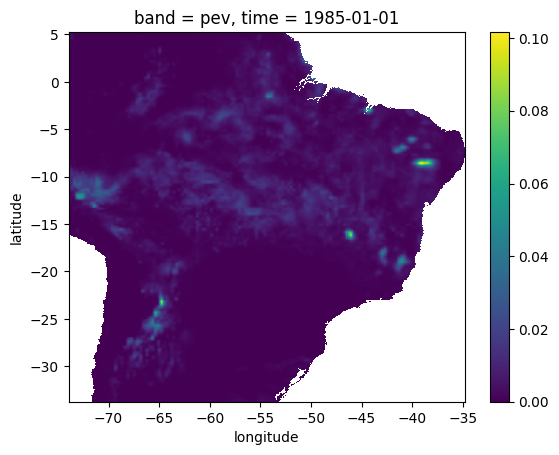

In [188]:
ds_xr.isel(time=0, band=3).plot.imshow()

---

In [1]:
import xarray as xr
from odc.geo.xr import ODCExtensionDa 
import numpy as np
import pandas as pd
import geopandas as gpd
import sys
sys.path.append("..")
from data.river_network import RiverNetwork

In [2]:
era5_land = xr.open_zarr(
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/climate/processed/era5_land.zarr_nobackup",
    consolidated=False
    )

era5_land

<xarray.Dataset> Size: 89GB
Dimensions:       (time: 14610, latitude: 390, longitude: 392)
Coordinates:
  * time          (time) datetime64[ns] 117kB 1985-01-01 ... 2024-12-31
  * latitude      (latitude) float64 3kB 5.2 5.1 5.0 4.9 ... -33.5 -33.6 -33.7
  * longitude     (longitude) float64 3kB -73.9 -73.8 -73.7 ... -34.9 -34.8
Data variables:
    sro           (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    2d            (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    spatial_ref   int64 8B ...
    pev           (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    2t            (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    swvl2         (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    tp            (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    swvl1         (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    ssro          (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    2t_daily_min  (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>
    2t_daily_max  (time, latitude, longitude) float32 9GB dask.array<chunksize=(365, 390, 392), meta=np.ndarray>

In [3]:
climate_chunk = (
    era5_land
    .odc.assign_crs(4326)
    .isel(
        time=slice(0, era5_land.chunks["time"][0]),
        latitude=slice(0, era5_land.chunks["latitude"][0]),
        longitude=slice(0, era5_land.chunks["longitude"][0])
        )
    .compute()
    )

In [4]:
network = RiverNetwork()
network.load("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network")

NameError: name 'within_geobox' is not defined

In [23]:
within_gebox = drainage_areas.centroid.within(era5_land.odc.geobox.extent.geom)

drainage_areas = network.drainage_areas.query("within_brazil & @within_gebox")
coordinates = drainage_areas.centroid.get_coordinates()

/scratch/ipykernel_448872/190623846.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  within_gebox = drainage_areas.centroid.within(era5_land.odc.geobox.extent.geom)
/scratch/ipykernel_448872/190623846.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coordinates = drainage_areas.centroid.get_coordinates()


/scratch/ipykernel_448872/3205081686.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  drainage_areas.centroid.plot(ax=ax)


<Axes: >

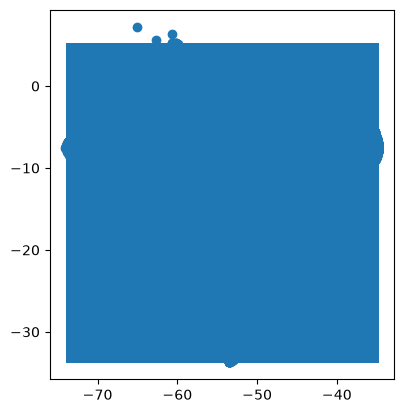

In [14]:
ax = gpd.GeoSeries([era5_land.odc.geobox.extent]).plot()
drainage_areas.centroid.plot(ax=ax)

In [6]:
def get_coord_subset(trench_id, latitude, longitude):
    coord_subset = (
        climate_chunk
            .sel(
                {
                    "latitude": latitude, 
                    "longitude": longitude
                    },
                method="nearest",
                tolerance=.1,
                )
            .to_dataframe()
            )
    
    coord_subset["trench_id"] = trench_id
    
    return coord_subset

In [9]:
subsets = [
    get_coord_subset(
        drainage_areas.trench_id.iloc[i],
        coordinates.y.iloc[i],
        coordinates.x.iloc[i],
        )
    for i in range(1000)
    ]
out = pd.concat(subsets)

out

,sro,2d,spatial_ref,pev,2t,swvl2,tp,swvl1,ssro,2t_daily_min,2t_daily_max,latitude,longitude,trench_id
time,,,,,,,,,,,,,,
1985-01-01,1784966.625,22.086334,4326,1789594.750,24.953766,0.226303,1781597.500,0.268618,1793301.875,-273.151062,26.736231,-6.7,-43.1,79673
1985-01-02,1779262.125,21.998230,4326,1789064.500,24.977173,0.233679,1776535.750,0.264378,1787693.875,-273.152924,28.414942,-6.7,-43.1,79673
1985-01-03,1777896.625,22.381470,4326,1784101.750,25.141846,0.249304,1774559.000,0.286168,1781197.500,-273.154266,28.990137,-6.7,-43.1,79673
1985-01-04,1774957.250,22.308502,4326,1778921.250,24.445801,0.276108,1774586.375,0.291838,1776494.375,-273.154572,27.578028,-6.7,-43.1,79673
1985-01-05,1773204.500,22.210693,4326,1774861.250,24.178406,0.272163,1778497.250,0.286565,1774870.625,-273.154602,24.762354,-6.7,-43.1,79673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985-12-27,1781071.250,22.616119,4326,1786027.750,24.232544,0.305086,1781703.125,0.324266,1785028.750,-273.154205,29.237696,-3.5,-42.3,218997
1985-12-28,1781166.625,22.485291,4326,1782986.875,24.390656,0.311544,1783622.000,0.326412,1783161.125,-273.154388,25.181543,-3.5,-42.3,218997
1985-12-29,1777811.750,22.525146,4326,1781092.375,25.117279,0.300767,1791645.875,0.303757,1780894.625,-273.154419,24.136621,-3.5,-42.3,218997


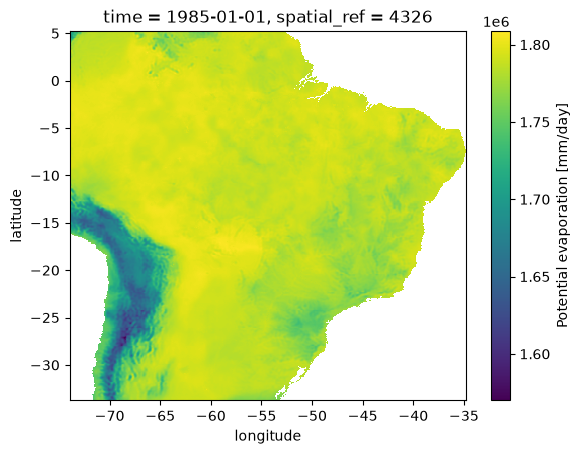

In [14]:
climate_slice.pev.isel(time=0).plot.imshow()

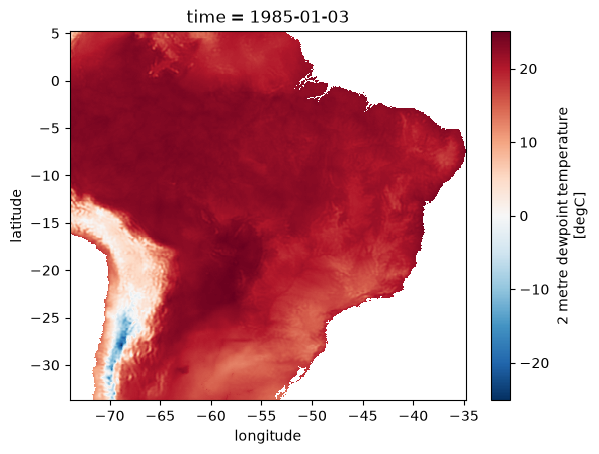

In [3]:
era5_land.isel(time=2)["2d"].plot.imshow()

---

In [1]:
import duckdb
conn = duckdb.connect()

In [11]:
conn.sql(
    """
    SELECT AVG(CAST(COLUMNS(*) IS NULL AS INTEGER))
    FROM read_parquet('../../data/climate/processed/climate_assembled_sensor.parquet')
    """
)

┌──────────────┬────────┬───────────┬─────────────┬────────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬─────────────────────────┬─────────────────────────┬─────────────────────────┬────────────────────────┬─────────────────────────┬─────────────────────────┬──────────────────────────┬──────────────────────────┬───────────────────────┬──────────────────────┬───────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬──────────────────────────┬─────────────────────────┬──────────────────────────┬──────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────┬──────────────────────┬───────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬────────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬─────────────────────────┬─────────────────────────┬──────────────────────────┬──────────

In [2]:
conn.sql(
    """
    SELECT AVG(CAST(sro IS NULL AS DOUBLE))
    FROM read_parquet('../../data/climate/processed/era5_land.parquet')
    """
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────────────────┐
│ avg(CAST((sro IS NULL) AS "DOUBLE")) │
│                double                │
├──────────────────────────────────────┤
│                 0.009638217628160358 │
└──────────────────────────────────────┘

In [3]:
conn.sql(
    """
    SELECT AVG(CAST(cl_0_10km_n == 0 AS DOUBLE))
    FROM read_parquet('../../data/climate/processed/climate_assembled_sensor.parquet')
    """
)

┌──────────────────────────────────────────┐
│ avg(CAST((cl_0_10km_n = 0) AS "DOUBLE")) │
│                  double                  │
├──────────────────────────────────────────┤
│                       0.9634334491658616 │
└──────────────────────────────────────────┘

In [2]:
conn.sql(
    """
    SELECT *
    FROM read_parquet('../../data/climate/processed/climate_assembled_sensor.parquet')
    """
)

┌──────────────┬────────────┬───────────┬─────────────┬────────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬─────────────────────────┬─────────────────────────┬──────────────────────────┬─────────────────────────┬──────────────────────────┬──────────────────────────┬───────────────────────────┬───────────────────────────┬────────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬─────────────────────────┬─────────────────────────┬───────────────────────┬──────────────────────┬───────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬───────────────────────┬──────────────────────┬───────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬───────────────────────┬──────────────────────┬───────────────────────┬───────────────────────┬────────────────────────┬────────────────────────┬─────────────────────────┬───────────────────

In [2]:
conn.sql(
    """
    SELECT *
    FROM read_parquet('../../data/sensor_data/water_quality_assembled.parquet')
    """
)

┌────────┬────────────────────┬────────────────────┬────────────────────┬───────────────────┬─────────┬────────────────────┬─────────────────────────┬────────────────┬──────────┬────────────────────────┬───────────────────────────┬────────────────────┬──────────────┬──────────────┬─────────────────┬────────────────────────┬────────────────────────┬───────────────────────────┬────────────────────────┬────────────────────────┬───────────────────────────┬───────────────────┬────────────┬──────────────────────┬────────────────────────┬──────────────────────┬───────────┬──────────┬──────────┬───────────┬─────────────────┬──────────┬────────────────┬───────────────────┬─────────────────────┬──────────┬──────────┬──────────────────────────┬────────────────────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬────────────────────┬─────────────────────┬───────────┬─────────┬─────────┬─────────┬───────────────┬─────────────────┬─────────────────┬───────────────────┬─────────┬──────────